# Smart Waste Detection and Classification using YOLOv8

**Project:** YOLOWaste — a YOLOv8-based object detection system for identifying and classifying waste materials (Cardboard, Metal, Paper, Plastic) from images.

**Goal:** Train a lightweight object detection model that can support automated waste sorting by detecting and classifying waste items in real-world images.

**Dataset:** [GARBAGE CLASSIFICATION 4](https://universe.roboflow.com/recycling-vs-waste/garbage-classification-4-oklrj) — Roboflow Universe (4,178 images, 4 classes).

This notebook walks through dataset exploration, the class-balanced train/val/test split, model training, and evaluation. Training itself was run on Google Colab (free Tesla T4 GPU) — see `scripts/train.py` for the exact training script used. Results from that run are loaded and visualized here for documentation and analysis.

## 1. Setup

In [1]:
import os
import yaml
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from ultralytics import YOLO

DATA_YAML = "../data.yaml"
DATA_DIR = "../data"
MODEL_PATH = "../models/best.pt"
RESULTS_PLOTS_DIR = "../results/plots"
SAMPLE_PRED_DIR = "../results/sample_predictions"


## 2. Dataset Exploration (EDA)

Let's load the dataset configuration and take a look at what we're working with.

In [2]:
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print("Classes:", data_config["names"])
print("Number of classes:", data_config["nc"])


Classes: ['CARDBOARD', 'METAL', 'PAPER', 'PLASTIC']
Number of classes: 4


### 2.1 Image counts per split

In [3]:
splits = ["train", "val", "test"]
counts = {}

for split in splits:
    img_dir = os.path.join(DATA_DIR, "images", split)
    counts[split] = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else 0

print("Image counts per split:")
for split, count in counts.items():
    print(f"  {split}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Number of Images per Split")
plt.ylabel("Image count")
plt.show()


Image counts per split:
  train: 2924
  val: 836
  test: 418


<Figure size 600x400 with 1 Axes>

### 2.2 Class distribution across the dataset

Each image can contain multiple objects/classes. Here we count total labeled instances per class, across all splits, to understand the overall balance of the dataset.

> **Note:** This project initially trained on Roboflow's default train/val/test split, which turned out to be severely imbalanced — some classes had only 0-1 validation instances, making their evaluation metrics statistically meaningless. This was fixed with a custom stratified split (`scripts/split_dataset.py`), which is what the `data/` folder now reflects. See Section 3 for details.

Total instances per class (across all splits):
  CARDBOARD: 2722
  METAL: 2835
  PAPER: 1689
  PLASTIC: 2810


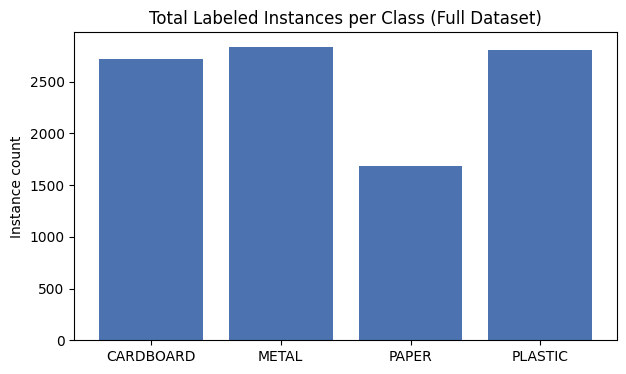

In [4]:
def count_class_instances(label_dir):
    class_counts = Counter()
    if not os.path.isdir(label_dir):
        return class_counts
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, fname), "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
    return class_counts

class_names = data_config["names"]
overall_counts = Counter()

for split in splits:
    label_dir = os.path.join(DATA_DIR, "labels", split)
    split_counts = count_class_instances(label_dir)
    overall_counts.update(split_counts)

print("Total instances per class (across all splits):")
for class_id, count in sorted(overall_counts.items()):
    print(f"  {class_names[class_id]}: {count}")

plt.figure(figsize=(7, 4))
labels = [class_names[i] for i in sorted(overall_counts.keys())]
values = [overall_counts[i] for i in sorted(overall_counts.keys())]
plt.bar(labels, values, color="#4C72B0")
plt.title("Total Labeled Instances per Class (Full Dataset)")
plt.ylabel("Instance count")
plt.show()


### 2.3 Sample images with bounding boxes

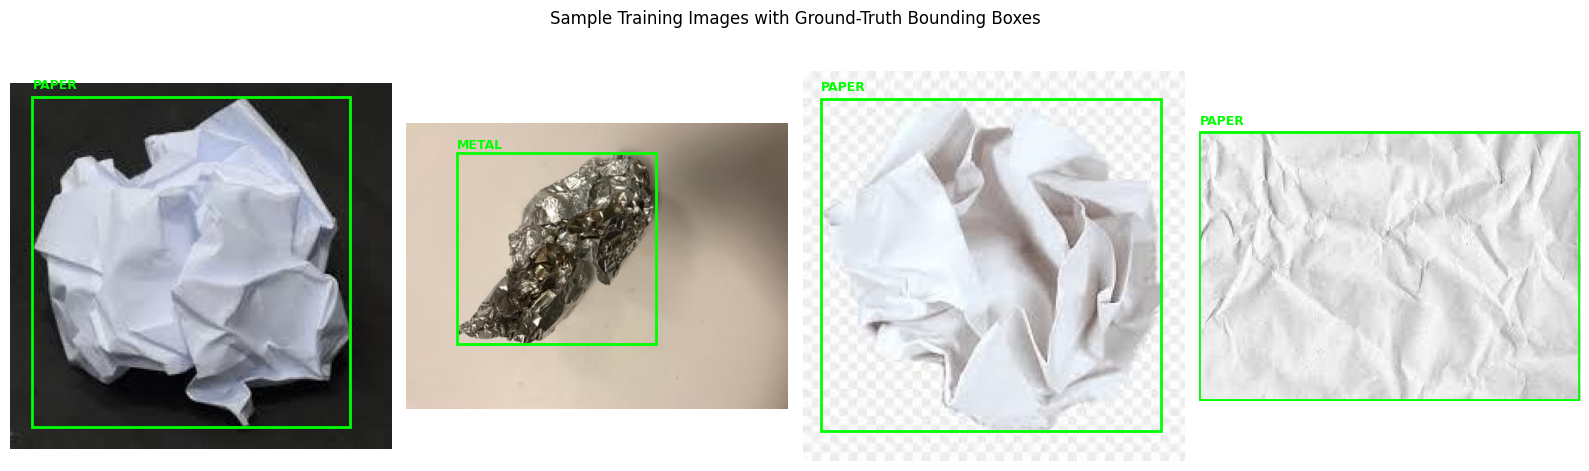

In [5]:
def draw_boxes_and_show(image_path, label_path, class_names, ax):
    import matplotlib.patches as patches
    from PIL import Image

    img = Image.open(image_path)
    w, h = img.size
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id, xc, yc, bw, bh = parts
                cls_id = int(cls_id)
                xc, yc, bw, bh = float(xc) * w, float(yc) * h, float(bw) * w, float(bh) * h
                x1, y1 = xc - bw / 2, yc - bh / 2
                rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, class_names[cls_id], color="lime", fontsize=9, weight="bold")

    ax.axis("off")


train_img_dir = os.path.join(DATA_DIR, "images", "train")
train_lbl_dir = os.path.join(DATA_DIR, "labels", "train")
sample_files = random.sample(os.listdir(train_img_dir), min(4, len(os.listdir(train_img_dir))))

fig, axes = plt.subplots(1, len(sample_files), figsize=(16, 5))
for ax, fname in zip(axes, sample_files):
    img_path = os.path.join(train_img_dir, fname)
    lbl_path = os.path.join(train_lbl_dir, os.path.splitext(fname)[0] + ".txt")
    draw_boxes_and_show(img_path, lbl_path, class_names, ax)

plt.suptitle("Sample Training Images with Ground-Truth Bounding Boxes")
plt.tight_layout()
plt.show()


## 3. Class-Balanced Train/Val/Test Split

The dataset as originally exported by Roboflow had an uneven class distribution across its train/val/test splits — for example, the validation set initially contained 0 instances of the "Plastic" class and only 1 instance of "Paper", making per-class evaluation for those classes statistically meaningless.

To fix this, a custom script (`scripts/split_dataset.py`) was written that:

1. Pools all images + labels back together
2. Assigns each image a **dominant class** (the class with the most labeled instances in that image)
3. Uses **stratified splitting** (via `sklearn.model_selection.train_test_split`) based on the dominant class, to ensure every class is proportionally represented in train, val, and test

Final split sizes: **2,924 train / 836 val / 418 test** images (70% / 20% / 10%).

See `scripts/split_dataset.py` for the full implementation.

## 4. Model Training

The model was trained using the `ultralytics` YOLOv8 library. Due to the dataset size (~4,178 images) and lack of local GPU access, training was run on **Google Colab** using a free Tesla T4 GPU, via `scripts/train.py`:

```python
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='waste_detector'
)
```

**Training configuration:**

| Config | Value |
|---|---|
| Model | YOLOv8n (nano) |
| Epochs | 50 |
| Image size | 640×640 |
| Batch size | 16 |
| Optimizer | AdamW (auto-selected) |
| Training hardware | Tesla T4 GPU (Google Colab) |
| Training time | ~41 minutes |

The resulting trained weights (`models/best.pt`) and training plots (`results/plots/`) are loaded and visualized below.

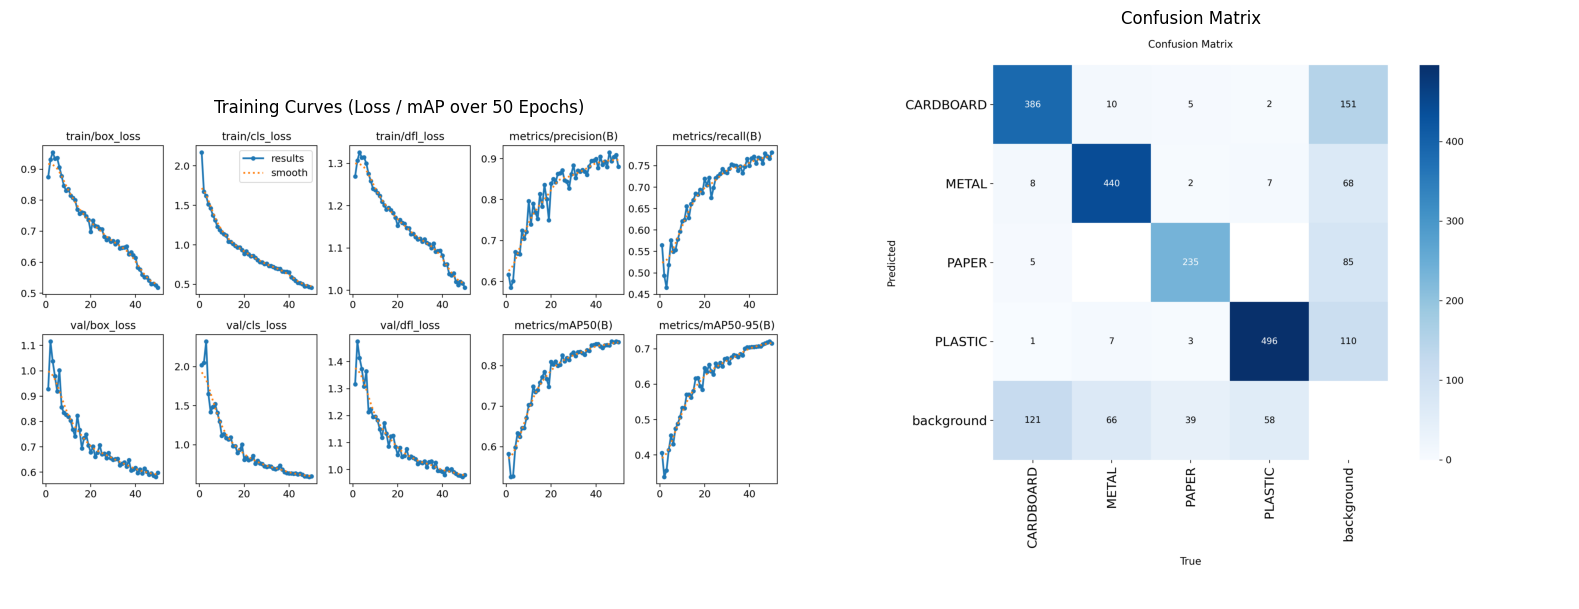

In [ ]:
# Display training curves and confusion matrix generated during training
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_img = mpimg.imread(os.path.join(RESULTS_PLOTS_DIR, "results.png"))
axes[0].imshow(results_img)
axes[0].axis("off")
axes[0].set_title("Training Curves (Loss / mAP over 50 Epochs)")

cm_img = mpimg.imread(os.path.join(RESULTS_PLOTS_DIR, "confusion_matrix.png"))
axes[1].imshow(cm_img)
axes[1].axis("off")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


## 5. Evaluation

Loading the trained model and validating it against the test set gives us the final, trustworthy per-class performance — since every class now has a meaningful number of instances across all splits.

In [ ]:
model = YOLO(MODEL_PATH)
metrics = model.val(data=DATA_YAML, split="test")


Ultralytics 8.4.161  Python-3.11.9 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-1334U)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 23.09.8 MB/s, size: 5.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning A:\YOLOWaste\data\labels\test.cache... 418 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 418/418  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6s/it 42.4s1.5ss
                   all        418       1210      0.873      0.688      0.795      0.622
             CARDBOARD        125        343      0.864      0.644      0.786      0.603
                 METAL        105        297      0.868      0.764      0.854      0.685
                 PAPER        100        222      0.838      0.629        0.7    

### Results Summary

| Class | mAP50 |
|---|---|
| Cardboard | 79.2% |
| Metal | 88.0% |
| Paper | 85.9% |
| Plastic | 90.8% |
| **Overall** | **86.0%** |

Unlike the original imbalanced split, every class here has 250+ validation instances, so these numbers are statistically meaningful across the board.

## 6. Sample Inference

Running the trained model on a few test images to visually confirm detection quality.


0: 640x640 1 PAPER, 1 PLASTIC, 91.4ms
1: 640x640 1 CARDBOARD, 91.4ms
2: 640x640 1 CARDBOARD, 91.4ms
3: 640x640 10 PAPERs, 91.4ms
Speed: 4.3ms preprocess, 91.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


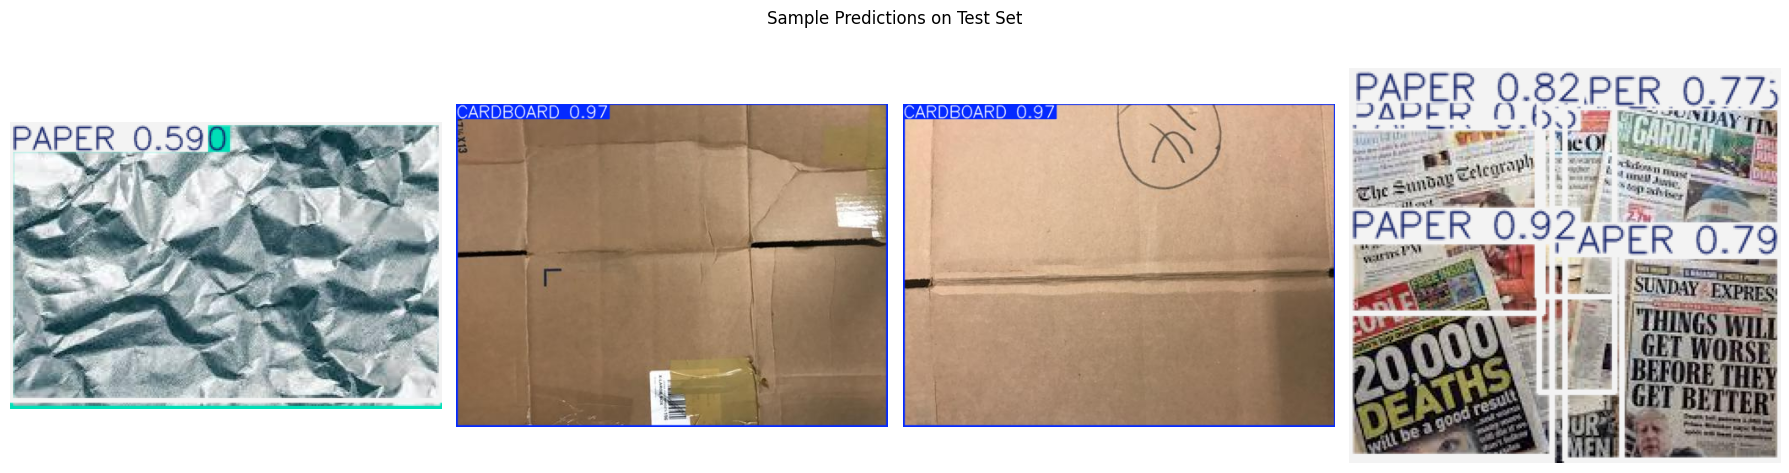

In [ ]:
test_img_dir = os.path.join(DATA_DIR, "images", "test")
sample_test_imgs = random.sample(os.listdir(test_img_dir), min(4, len(os.listdir(test_img_dir))))
sample_test_paths = [os.path.join(test_img_dir, f) for f in sample_test_imgs]

results = model.predict(source=sample_test_paths, conf=0.25, save=False)

fig, axes = plt.subplots(1, len(results), figsize=(18, 5))
for ax, r in zip(axes, results):
    annotated = r.plot()[:, :, ::-1]  # BGR -> RGB
    ax.imshow(annotated)
    ax.axis("off")

plt.suptitle("Sample Predictions on Test Set")
plt.tight_layout()
plt.show()


## 7. Conclusion

This project successfully trained a YOLOv8n object detection model to identify and classify four categories of waste material (Cardboard, Metal, Paper, Plastic), achieving an overall **mAP50 of 86.0%** with balanced, trustworthy per-class performance.

**Key learnings / engineering decisions:**
- The originally provided dataset split had severe class imbalance across train/val/test, which was diagnosed by inspecting per-class validation instance counts, and fixed with a custom stratified re-splitting script.
- A lightweight YOLOv8n model was sufficient to achieve strong performance without needing a larger, slower model variant.
- Training on free-tier Google Colab GPU (~41 minutes for 50 epochs) made this feasible without dedicated hardware.

**Future improvements:**
- Expand the dataset with additional waste categories (glass, organic/biodegradable)
- Experiment with larger YOLOv8 variants (s/m) for potentially higher accuracy
- Explore model quantization/export (ONNX, TFLite) for deployment on edge devices like smart bins
- Data augmentation targeted specifically at improving the Cardboard class, which had the lowest per-class mAP

See the project [README](../README.md) for the full write-up, live demo link, and usage instructions.